In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

import multiprocessing

multiprocessing.set_start_method("spawn")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd


df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

In [4]:
from itertools import product
import numpy as np
from training_info import TrainingInfo
from plots import get_weights_by_sr_stats

def get_w_signal_ratio(hash: str):
    smeared_fvt_info = TrainingInfo.load(hash)
    msamples = MotherSamples.load(smeared_fvt_info.ms_hash)
    tst_scdinfo = msamples.scdinfo[~smeared_fvt_info.ms_idx]
    df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    # if "SR_stats_tst" in smeared_fvt_info.aux_info:
    #     SR_stats_tst = smeared_fvt_info.aux_info["SR_stats_tst"]
    # else:
    smeared_fvt_model = smeared_fvt_info.load_trained_model("best")
    smeared_fvt_model: FvTClassifier
    smeared_fvt_model.eval()
    smeared_fvt_model.to("cuda")
    
    base_encoder_hash = smeared_fvt_info.hparams["encoder_hash"]
    base_fvt_info = TrainingInfo.load(base_encoder_hash)
    base_fvt_model = base_fvt_info.load_trained_model("best")
    base_fvt_model: FvTClassifier
    base_fvt_model.eval()
    base_fvt_model.to("cuda")
    
    base_fvt_score, q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
    base_fvt_score = base_fvt_score.numpy()[:, 1]
    q_repr = q_repr.numpy()
    smeared_fvt_score = smeared_fvt_model.predict(q_repr).numpy()[:, 1]
    gamma_base = base_fvt_score / (1 - base_fvt_score)
    gamma_smeared = smeared_fvt_score / (1 - smeared_fvt_score)
    SR_stats_tst = np.log(gamma_base / gamma_smeared)

    w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_tst)
    return w_4b_ratio, w_signal_ratio

In [5]:
from itertools import product
import numpy as np
from training_info import TrainingInfo
from plots import get_weights_by_sr_stats

w_signal_ratio_dict = {}
signal_ratios = [0.02, 0.01, 0.0075, 0.005]
experiment_names = ["smeared_fvt_training_repr_norm", "smeared_fvt_training"]
seeds = range(50)

for signal_ratio in signal_ratios:
    for experiment_name in experiment_names:
        hparams_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: (
                x["signal_ratio"] == signal_ratio
                and x["seed"] in seeds
                and x["n_3b"] == 1_000_000
            ),
        }
        hashes, hparams = TrainingInfo.find(hparams_filter, return_hparams=True)
        # sort hashes by signal_ratio and seed
        to_sort = [(hp["dataset"]["seed"]) for hp in hparams]
        idx = np.arange(len(hashes))
        hashes = [hashes[i] for i, _ in sorted(zip(idx, to_sort), key=lambda x: x[1])]
        
        w_4b_ratio_points = np.arange(0, 1.01, 0.01)
        w_signal_ratio_dict[(signal_ratio, experiment_name)] = []
        for hash in tqdm.tqdm(hashes):
            w_4b_ratio, w_signal_ratio = get_w_signal_ratio(hash)
            w_signal_ratio = np.interp(w_4b_ratio_points, w_4b_ratio, w_signal_ratio)
            w_signal_ratio_dict[(signal_ratio, experiment_name)].append(w_signal_ratio)
            
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))    
    fig.suptitle(f"signal_ratio: {signal_ratio}")
    for experiment_name in experiment_names:
        mean = np.mean(w_signal_ratio_dict[(signal_ratio, experiment_name)], axis=0)
        std = np.std(w_signal_ratio_dict[(signal_ratio, experiment_name)], axis=0)
        ax.plot(w_4b_ratio_points, mean, label=experiment_name)
        ax.fill_between(w_4b_ratio_points, mean - std, mean + std, alpha=0.2)
    plt.legend()
    plt.show()


  0%|          | 0/50 [00:18<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 72.00 MiB. GPU 

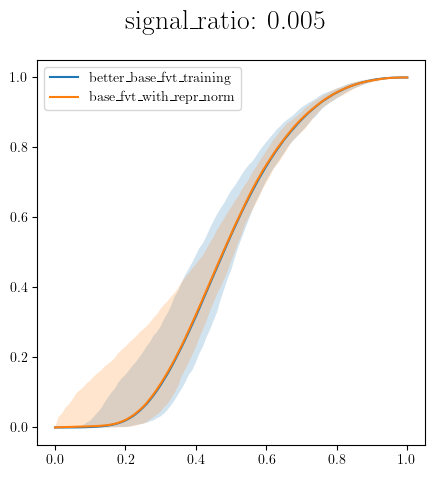

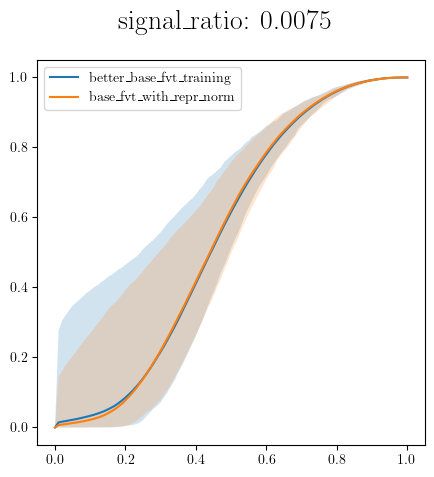

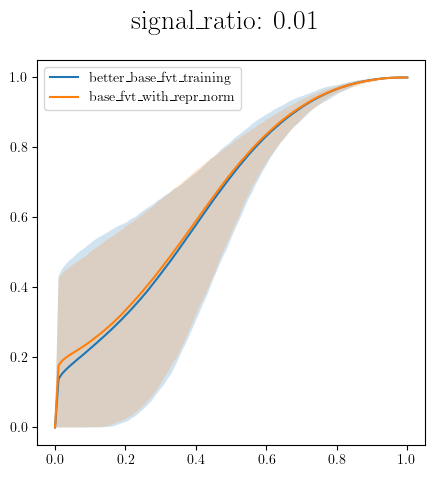

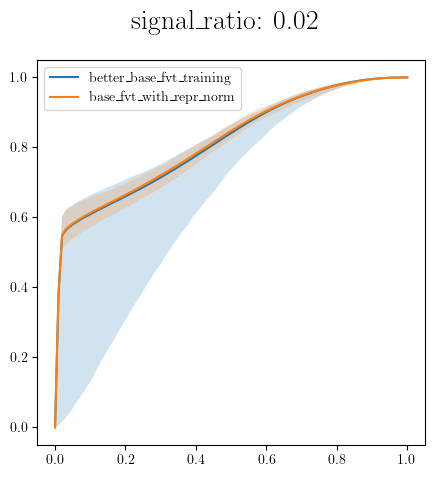

In [10]:
for signal_ratio in signal_ratios:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))    
    fig.suptitle(f"signal_ratio: {signal_ratio}")
    for experiment_name in ["better_base_fvt_training", "base_fvt_with_repr_norm"]:
        mean = np.mean(w_signal_ratio_dict[(signal_ratio, experiment_name)], axis=0)
        q1, q3 = np.quantile(w_signal_ratio_dict[(signal_ratio, experiment_name)], [0.25, 0.75], axis=0)
        min_, max_ = np.min(w_signal_ratio_dict[(signal_ratio, experiment_name)], axis=0), np.max(w_signal_ratio_dict[(signal_ratio, experiment_name)], axis=0)
        ax.plot(w_4b_ratio_points, mean, label=experiment_name)
        # ax.fill_between(w_4b_ratio_points, q1, q3, alpha=0.2)
        ax.fill_between(w_4b_ratio_points, min_, max_, alpha=0.2)
    plt.legend()
    plt.show()


exp_name: base_fvt_with_repr_norm, repr_norm: True, signal_ratio: 0.005


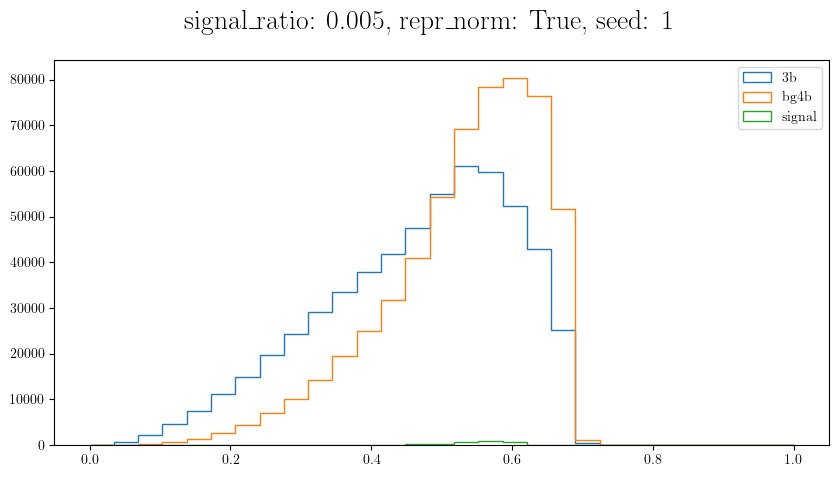

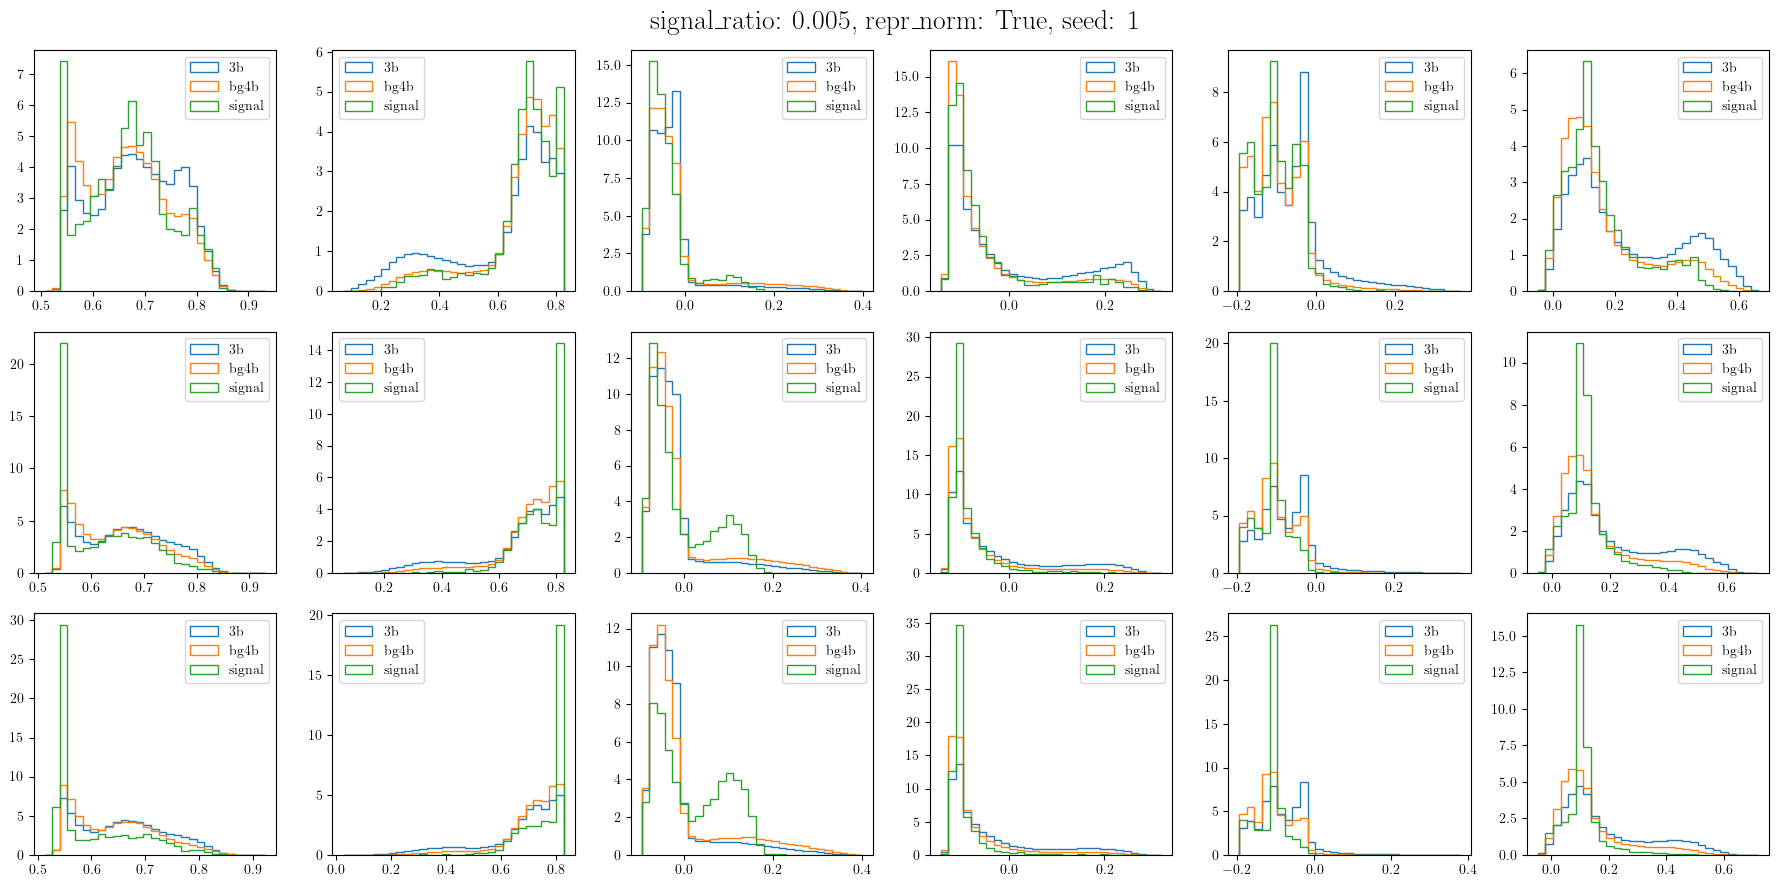

view 0


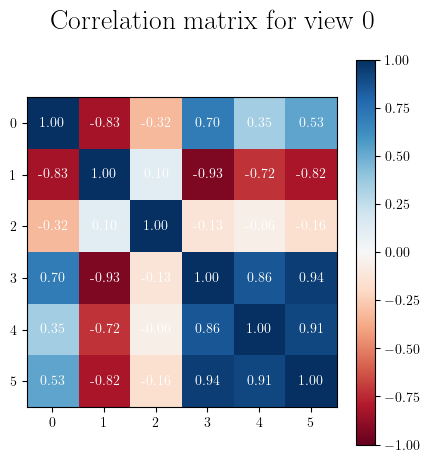

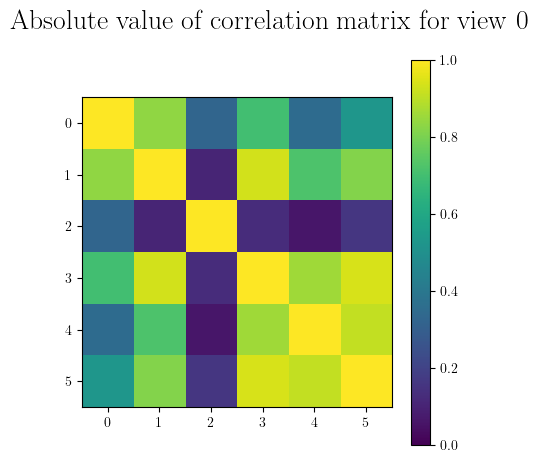

view 1


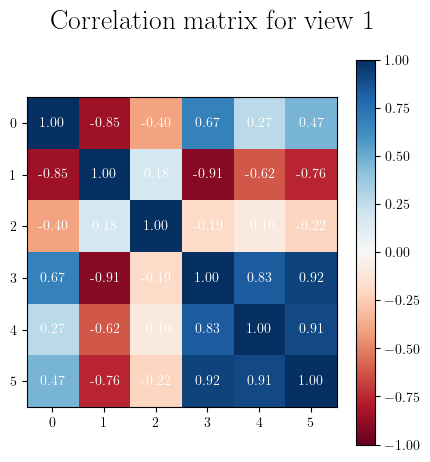

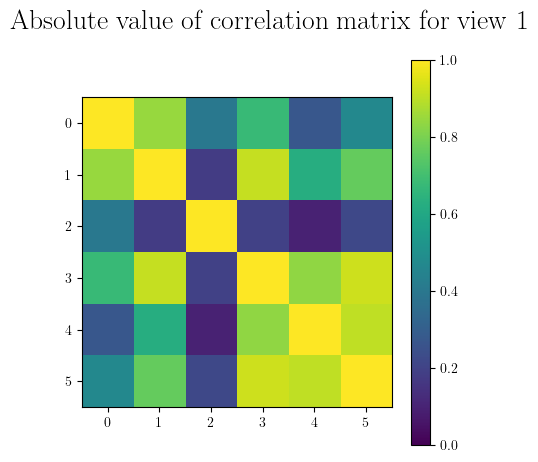

view 2


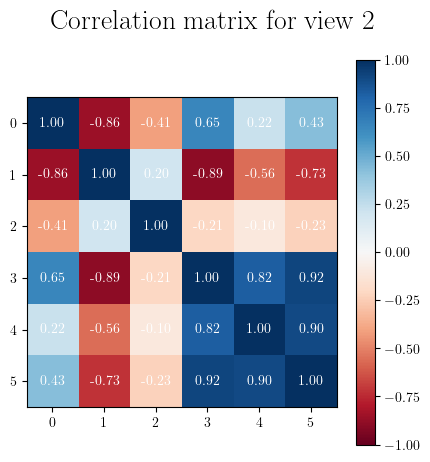

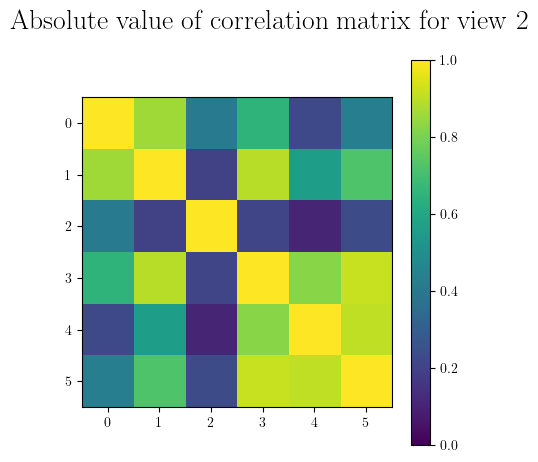

In [15]:
hparams_filter = {
    "experiment_name": lambda x: (x in [
        "base_fvt_with_repr_norm", 
        # "better_base_fvt_training", 
        # "base_fvt_with_repr_norm_smaller_repr_dim",
    ]),
    # "experiment_name": "base_fvt_with_repr_norm",
    "dataset": lambda x: (
        x["signal_ratio"] in [0.005]
        and x["seed"] in [1]
        and x["n_3b"] == 1_000_000),
}
hashes, hparams = TrainingInfo.find(hparams_filter, return_hparams=True)
# sort hashes by signal_ratio and seed
to_sort = [(hp["dataset"]["signal_ratio"], hp["dataset"]["seed"]) for hp in hparams]
idx = np.arange(len(hashes))
hashes = [hashes[i] for i, _ in sorted(zip(idx, to_sort), key=lambda x: x[1])]

for hash in hashes:
    base_fvt_info = TrainingInfo.load(hash)
    base_fvt_model = base_fvt_info.load_trained_model("best")
    base_fvt_model: FvTClassifier
    base_fvt_model.eval()
    base_fvt_model.to("cuda")
    
    exp_name = base_fvt_info.hparams["experiment_name"]
    repr_norm = base_fvt_info.hparams.get("repr_norm", False)
    
    signal_ratio = base_fvt_info.hparams["dataset"]["signal_ratio"]
    print(
        f"exp_name: {exp_name}, repr_norm: {repr_norm}, signal_ratio: {signal_ratio}"
    )
    
    ms_hash = base_fvt_info.ms_hash
    ms_idx = base_fvt_info.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
    base_fvt_scores = base_fvt_scores.numpy()[:, 1]
    base_q_repr = base_q_repr.numpy()
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    fig.suptitle(f"signal_ratio: {signal_ratio}, repr_norm: {repr_norm}, seed: {base_fvt_info.hparams['dataset']['seed']}")
    hist_events_by_labels(events_tst, base_fvt_scores, bins=np.linspace(0, 1, 30), ax=ax)
    ax.legend()
    plt.show()
    
    ncols, nrows = base_q_repr.shape[1], base_q_repr.shape[2]
    fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    fig.suptitle(f"signal_ratio: {signal_ratio}, repr_norm: {repr_norm}, seed: {base_fvt_info.hparams['dataset']['seed']}")
    for i in range(nrows):
        for j in range(ncols):
            bins = np.linspace(base_q_repr[:, j, i].min(), base_q_repr[:, j, i].max(), 30)
            hist_events_by_labels(events_tst, base_q_repr[:, j, i], bins=bins, ax=axs[i, j], density=True)
            axs[i, j].legend()
    plt.tight_layout()
    plt.show()
    
    # for each view, print correlation between each pair of features
    for view in range(3):
        print(f"view {view}")
        corr = np.corrcoef(base_q_repr[:, :, view].T)
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        fig.suptitle(f"Correlation matrix for view {view}")
        plt.imshow(corr, vmin=-1, vmax=1, cmap="RdBu")
        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="white")
        plt.colorbar()
        plt.show()
        
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        fig.suptitle(f"Absolute value of correlation matrix for view {view}")
        plt.imshow(np.abs(corr), vmin=0, vmax=1, cmap="viridis")
        plt.colorbar()
        plt.show()
    
base_q_repr, view_score = base_fvt_model.representations(events_tst.X_torch)
view_score = view_score.reshape(-1, 3).numpy()
base_q_repr = base_q_repr.numpy()

0.019703369587628194


/tmp/ipykernel_720206/714356788.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio_4b = hist_4b.T / hist_3b.T
/tmp/ipykernel_720206/714356788.py:23: RuntimeWarning: invalid value encountered in divide
  ratio_4b = hist_4b.T / hist_3b.T
/tmp/ipykernel_720206/714356788.py:27: RuntimeWarning: divide by zero encountered in divide
  axs[0].imshow(hist_bg4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:27: RuntimeWarning: invalid value encountered in divide
  axs[0].imshow(hist_bg4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:30: RuntimeWarning: divide by zero encountered in divide
  axs[1].imshow(hist_4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:30: RuntimeWarning: invalid value encountered in divide
  axs[1].imshow(hist_4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:33: RuntimeWarning: invalid value encountered in divide
  axs[2].imshow(hist_signal.T / hist_3b.T, origin="lower",


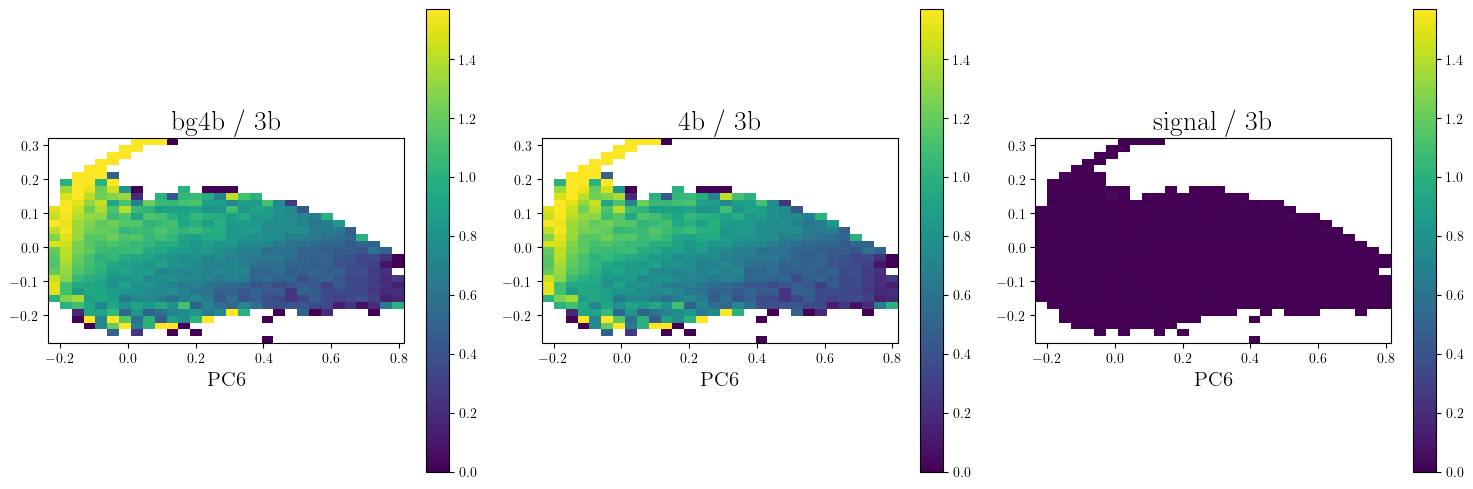

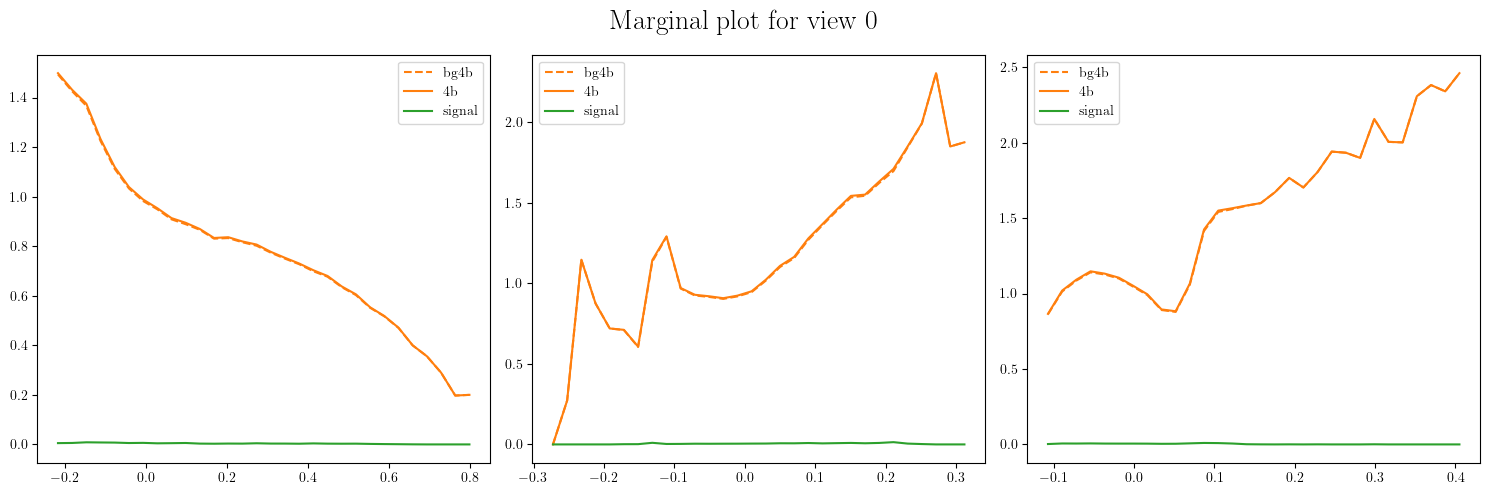

0.018816958514394466


/tmp/ipykernel_720206/714356788.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio_4b = hist_4b.T / hist_3b.T
/tmp/ipykernel_720206/714356788.py:23: RuntimeWarning: invalid value encountered in divide
  ratio_4b = hist_4b.T / hist_3b.T
/tmp/ipykernel_720206/714356788.py:27: RuntimeWarning: divide by zero encountered in divide
  axs[0].imshow(hist_bg4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:27: RuntimeWarning: invalid value encountered in divide
  axs[0].imshow(hist_bg4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:30: RuntimeWarning: divide by zero encountered in divide
  axs[1].imshow(hist_4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:30: RuntimeWarning: invalid value encountered in divide
  axs[1].imshow(hist_4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:33: RuntimeWarning: invalid value encountered in divide
  axs[2].imshow(hist_signal.T / hist_3b.T, origin="lower",


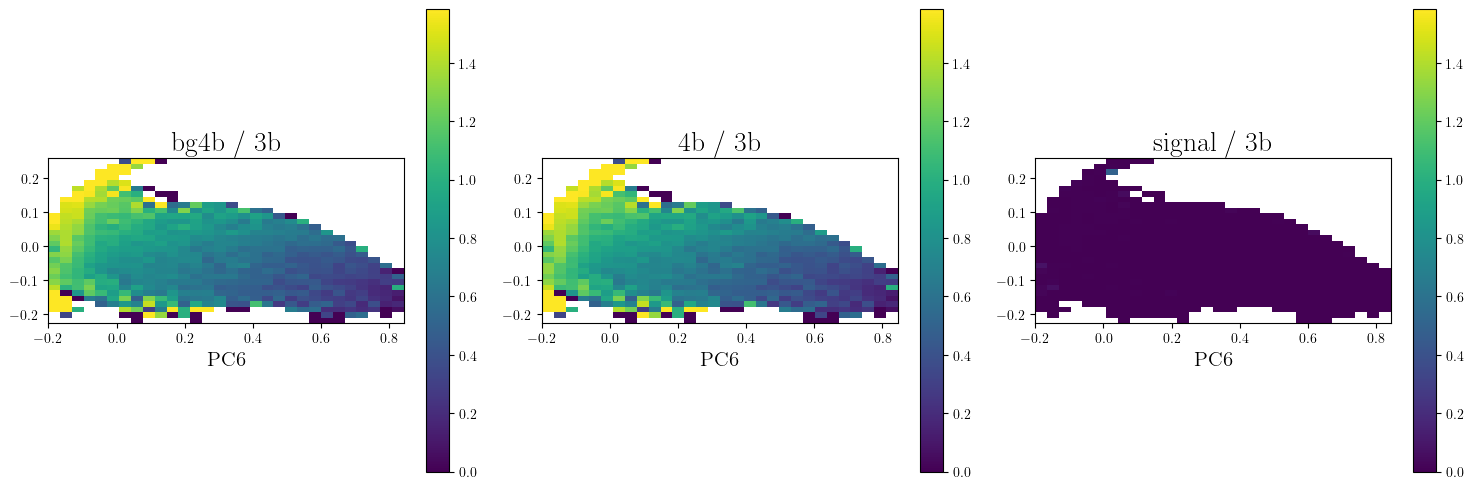

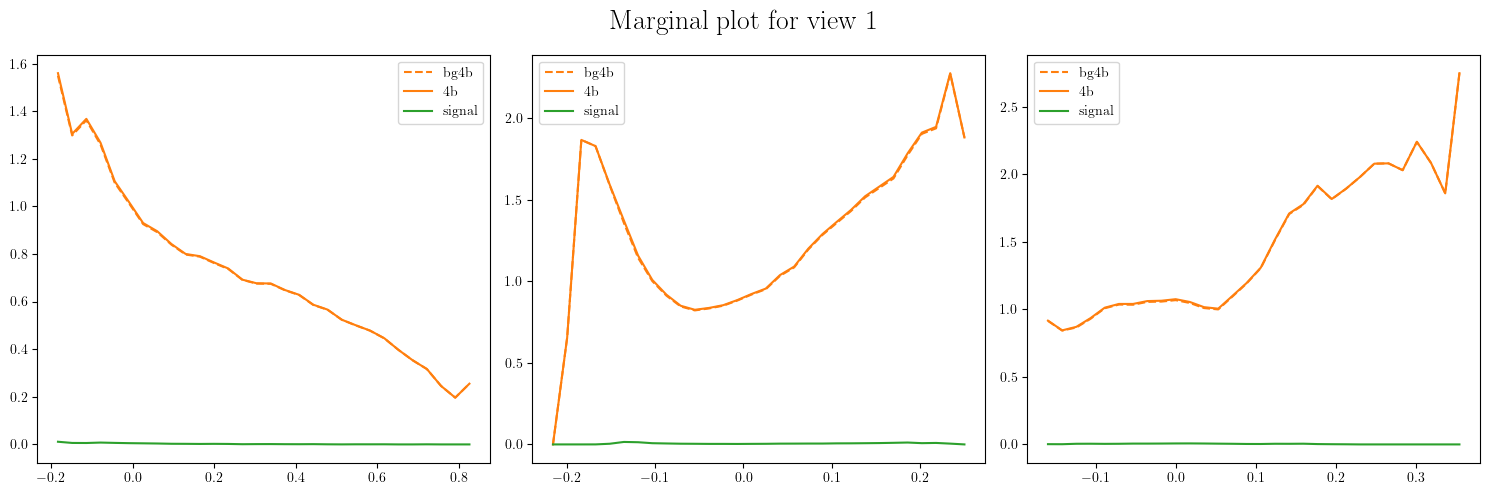

0.018062092588091883


/tmp/ipykernel_720206/714356788.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio_4b = hist_4b.T / hist_3b.T
/tmp/ipykernel_720206/714356788.py:23: RuntimeWarning: invalid value encountered in divide
  ratio_4b = hist_4b.T / hist_3b.T
/tmp/ipykernel_720206/714356788.py:27: RuntimeWarning: divide by zero encountered in divide
  axs[0].imshow(hist_bg4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:27: RuntimeWarning: invalid value encountered in divide
  axs[0].imshow(hist_bg4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:30: RuntimeWarning: divide by zero encountered in divide
  axs[1].imshow(hist_4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:30: RuntimeWarning: invalid value encountered in divide
  axs[1].imshow(hist_4b.T / hist_3b.T, origin="lower",
/tmp/ipykernel_720206/714356788.py:33: RuntimeWarning: invalid value encountered in divide
  axs[2].imshow(hist_signal.T / hist_3b.T, origin="lower",


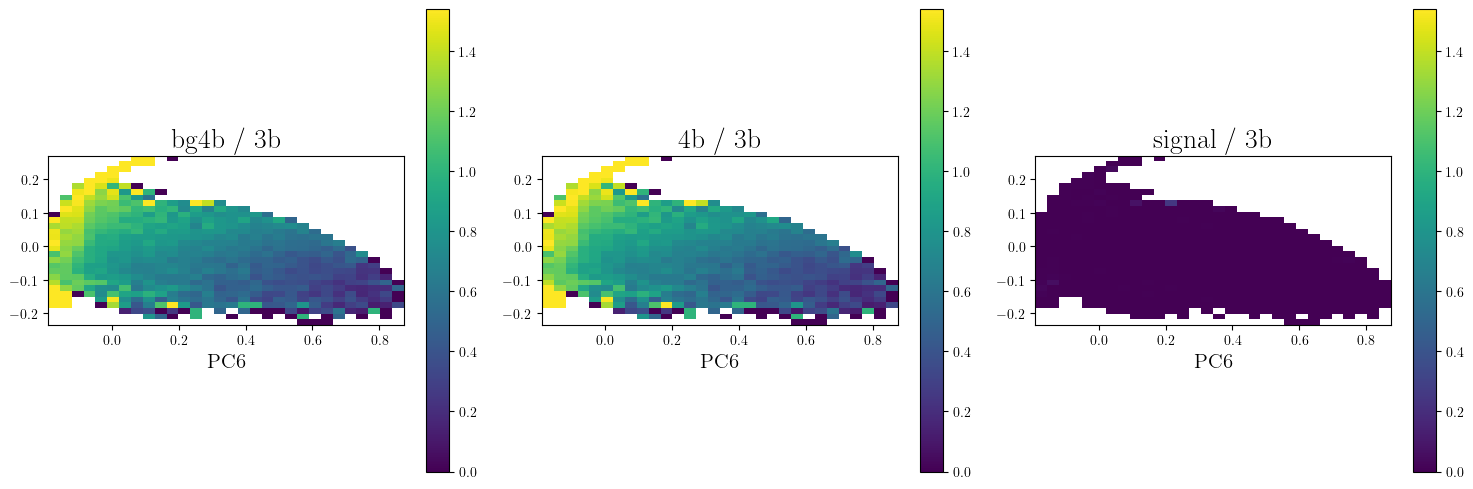

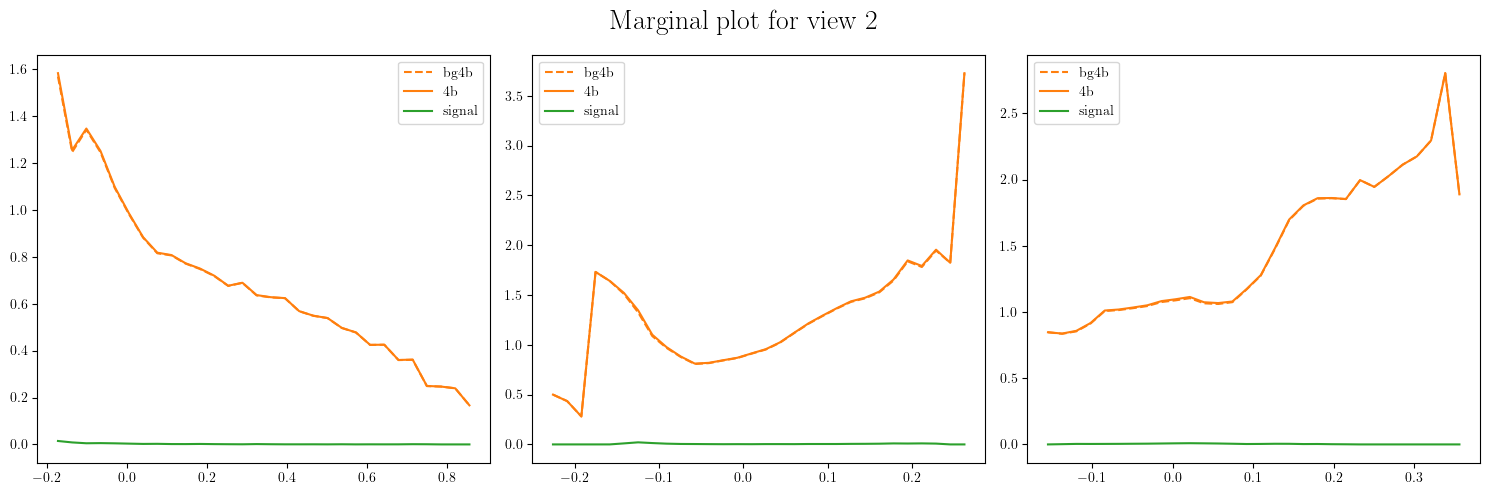

In [17]:
from sklearn.decomposition import PCA

is_3b = events_tst.is_3b
is_bg4b = events_tst.is_bg4b
is_signal = events_tst.is_signal

nbins = 30
pca_dim = 3

for view in range(3):
    X = base_q_repr[:, :, view]

    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(X)
    print(1 - np.sum(pca.explained_variance_ratio_))
            
    hist_3b, x_edges, y_edges = np.histogram2d(X_pca[is_3b, 0], X_pca[is_3b, 1], bins=nbins)
    hist_bg4b, _, _ = np.histogram2d(X_pca[is_bg4b, 0], X_pca[is_bg4b, 1], bins=(x_edges, y_edges))
    hist_signal, _, _ = np.histogram2d(X_pca[is_signal, 0], X_pca[is_signal, 1], bins=(x_edges, y_edges))
    hist_4b = hist_bg4b + hist_signal

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    ratio_4b = hist_4b.T / hist_3b.T
    ratio_4b = ratio_4b[np.isfinite(ratio_4b)]
    vmax = np.quantile(ratio_4b, 0.95)
    vmin = 0
    axs[0].imshow(hist_bg4b.T / hist_3b.T, origin="lower", 
                extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]), vmin=vmin, vmax=vmax)
    axs[0].set_title("bg4b / 3b")
    axs[1].imshow(hist_4b.T / hist_3b.T, origin="lower",
                extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]), vmin=vmin, vmax=vmax)
    axs[1].set_title("4b / 3b")
    axs[2].imshow(hist_signal.T / hist_3b.T, origin="lower",
                extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]), vmin=vmin, vmax=vmax)
    axs[2].set_title("signal / 3b")
    for ax in axs:
        plt.colorbar(ax.images[0], ax=ax)
        ax.set_aspect("equal")
        ax.set_xlabel(f"PC{j+1}")
    plt.tight_layout()
    plt.show()
    
    # Marginal plots
    fig, axs = plt.subplots(1, pca_dim, figsize=(pca_dim*5, 5))
    fig.suptitle(f"Marginal plot for view {view}")
    for dim in range(pca_dim):
        hist_3b, x_edges = np.histogram(X_pca[is_3b, dim], bins=nbins)
        hist_bg4b, _ = np.histogram(X_pca[is_bg4b, dim], bins=x_edges)
        hist_signal, _ = np.histogram(X_pca[is_signal, dim], bins=x_edges)
        hist_4b = hist_bg4b + hist_signal
        midpoints = (x_edges[:-1] + x_edges[1:]) / 2
        axs[dim].plot(midpoints, hist_bg4b / hist_3b, color=plt.cm.tab10(1), linestyle="--", label="bg4b")
        axs[dim].plot(midpoints, hist_4b / hist_3b, color=plt.cm.tab10(1), label="4b")
        axs[dim].plot(midpoints, hist_signal / hist_3b, color=plt.cm.tab10(2), label="signal")
        axs[dim].legend()
    plt.tight_layout()
    plt.show()



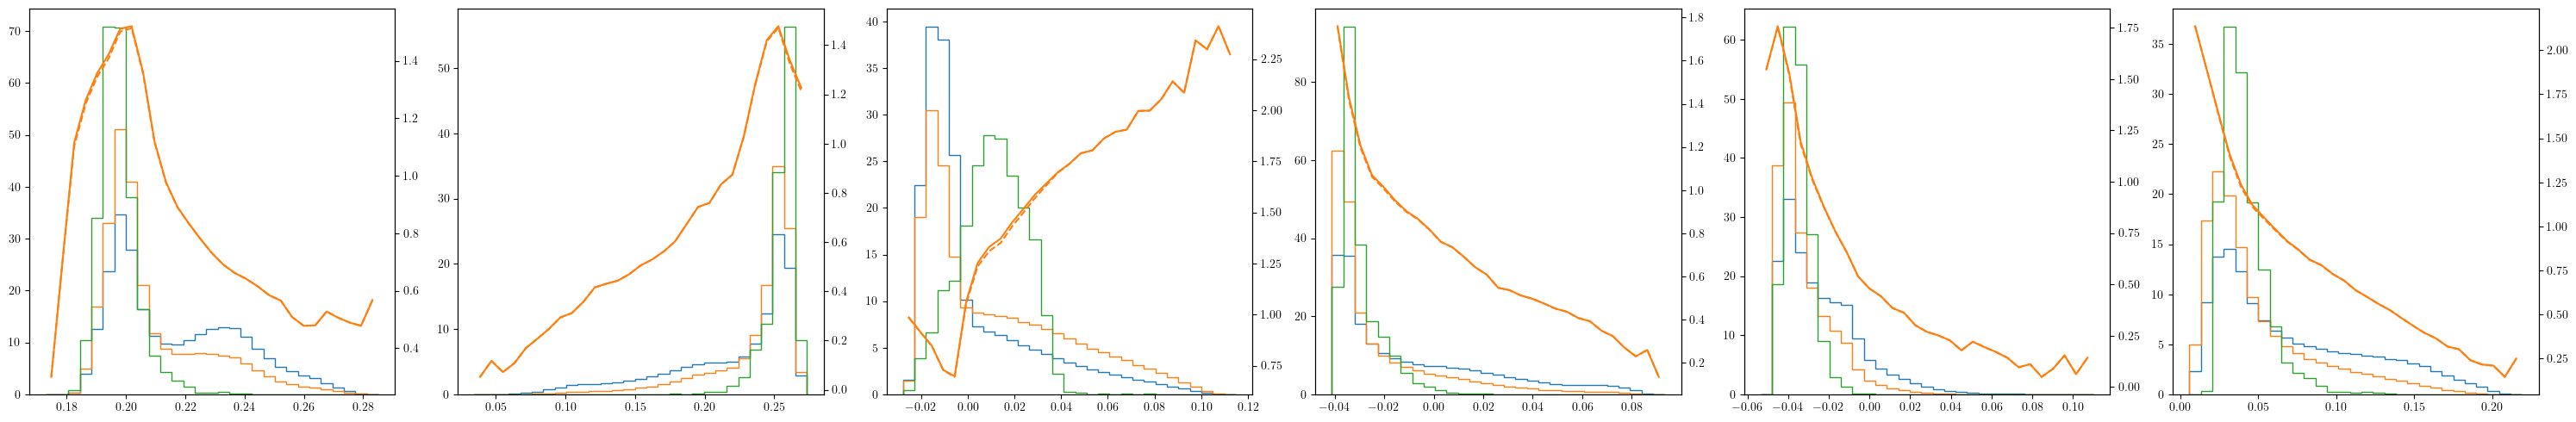

In [7]:
agg_repr = np.mean(base_q_repr * view_score.reshape(-1, 1, 3), axis=-1)
fig, axs = plt.subplots(1, base_q_repr.shape[1], figsize=(base_q_repr.shape[1]*5, 5))
for i in range(base_q_repr.shape[1]):
    bins = np.linspace(agg_repr[:, i].min(), agg_repr[:, i].max(), 30)
    hist_events_by_labels(events_tst, agg_repr[:, i], bins=bins, ax=axs[i], 
                          density=True)
    hist_3b, _ = np.histogram(agg_repr[events_tst.is_3b, i], bins=bins)
    hist_bg4b, _ = np.histogram(agg_repr[events_tst.is_bg4b, i], bins=bins)
    hist_signal, _ = np.histogram(agg_repr[events_tst.is_signal, i], bins=bins)
    hist_4b = hist_bg4b + hist_signal
    twinx = axs[i].twinx()
    midpoints = (bins[:-1] + bins[1:]) / 2
    twinx.plot(midpoints, hist_bg4b / hist_3b, color=plt.cm.tab10(1), linestyle="--", label="bg4b")
    twinx.plot(midpoints, hist_4b / hist_3b, color=plt.cm.tab10(1), label="4b")
plt.tight_layout()
plt.show()


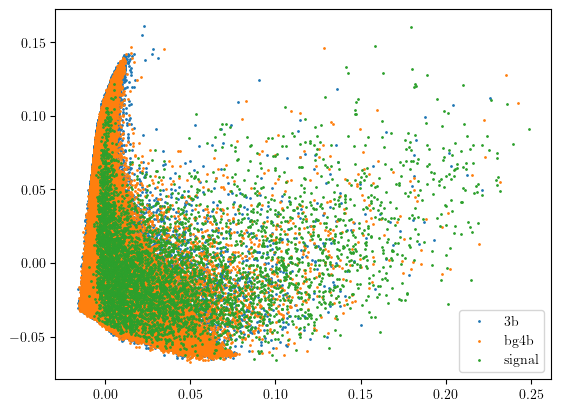

In [43]:
f1 = 2
f2 = 3

is_3b, is_bg4b, is_signal = events_tst.is_3b, events_tst.is_bg4b, events_tst.is_signal
plt.scatter(agg_repr[is_3b, f1], agg_repr[is_3b, f2], label="3b", s=1)
plt.scatter(agg_repr[is_bg4b, f1], agg_repr[is_bg4b, f2], label="bg4b", s=1)
plt.scatter(agg_repr[is_signal, f1], agg_repr[is_signal, f2], label="signal", s=1)
plt.legend()
plt.show()

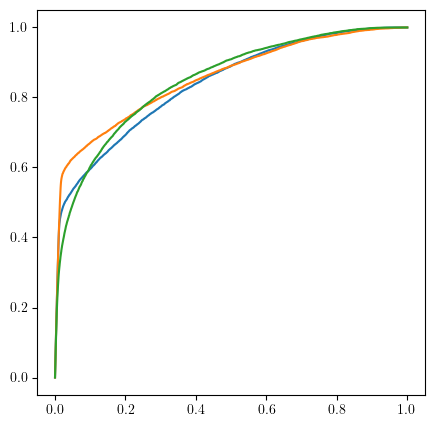

In [21]:
from plots import plot_sr_stats
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sgn_list = [1, -1, -1]
for f in range(3):
    sgn = sgn_list[f]
    plot_sr_stats(events_tst, 
                sgn * np.mean(base_q_repr[:, f, :] * view_score, axis=1), 
                ax=ax, label=f"mean(repr * view_score) for feature {f}")
plt.show()


In [22]:
# sample 1000 events from each class
f1, f2, f3 = 0, 1, 2
view = 2

n_samples = 1000
sampled_indices = np.concatenate([
    np.random.choice(np.where(events_tst.is_3b)[0], n_samples),
    np.random.choice(np.where(events_tst.is_bg4b)[0], n_samples),
    np.random.choice(np.where(events_tst.is_signal)[0], n_samples),
])
events_sampled = events_tst[sampled_indices]
base_q_repr_sampled = base_q_repr[sampled_indices]

is_3b = events_sampled.is_3b
is_bg4b = events_sampled.is_bg4b
is_signal = events_sampled.is_signal

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(
    go.Scatter3d(
        x=base_q_repr_sampled[is_3b, f1, view],
        y=base_q_repr_sampled[is_3b, f2, view],
        z=base_q_repr_sampled[is_3b, f3, view],
        mode="markers",
        name="bg 3b",
        marker=dict(size=1, color="blue"),
                )
            )
fig.add_trace(
    go.Scatter3d(
        x=base_q_repr_sampled[is_bg4b, f1, view],
        y=base_q_repr_sampled[is_bg4b, f2, view],
        z=base_q_repr_sampled[is_bg4b, f3, view],
        mode="markers",
        name="bg 4b",
        marker=dict(size=1, color="orange"),
    )
)
fig.add_trace(
    go.Scatter3d(
        x=base_q_repr_sampled[is_signal, f1, view],
        y=base_q_repr_sampled[is_signal, f2, view],
        z=base_q_repr_sampled[is_signal, f3, view],
        mode="markers",
        name="Signal",
        marker=dict(size=1, color="green")
    )
)

fig.show()

In [23]:
fig = go.Figure()
# for view in range(3):
fig.add_trace(
    go.Scatter(
        x=base_q_repr_sampled[is_3b, f1, view],
        y=base_q_repr_sampled[is_3b, f2, view],
        mode="markers",
        name="bg 3b",
        marker=dict(size=2, color="blue"),
                )
            )
fig.add_trace(
    go.Scatter(
        x=base_q_repr_sampled[is_bg4b, f1, view],
        y=base_q_repr_sampled[is_bg4b, f2, view],
        mode="markers",
        name="bg 4b",
        marker=dict(size=2, color="orange"),
    )
)
fig.add_trace(
    go.Scatter(
        x=base_q_repr_sampled[is_signal, f1, view],
        y=base_q_repr_sampled[is_signal, f2, view],
        mode="markers",
        name="Signal",
        marker=dict(size=2, color="green")
    )
)
# draw a unit circle
theta = np.linspace(0, 2*np.pi, 100)
x = np.cos(theta)
y = np.sin(theta)
fig.add_trace(go.Scatter(x=x, y=y, mode="lines", name="unit circle", line=dict(color="red")))

fig.update_layout(yaxis_scaleanchor="x", width=500, height=500)

fig.show()

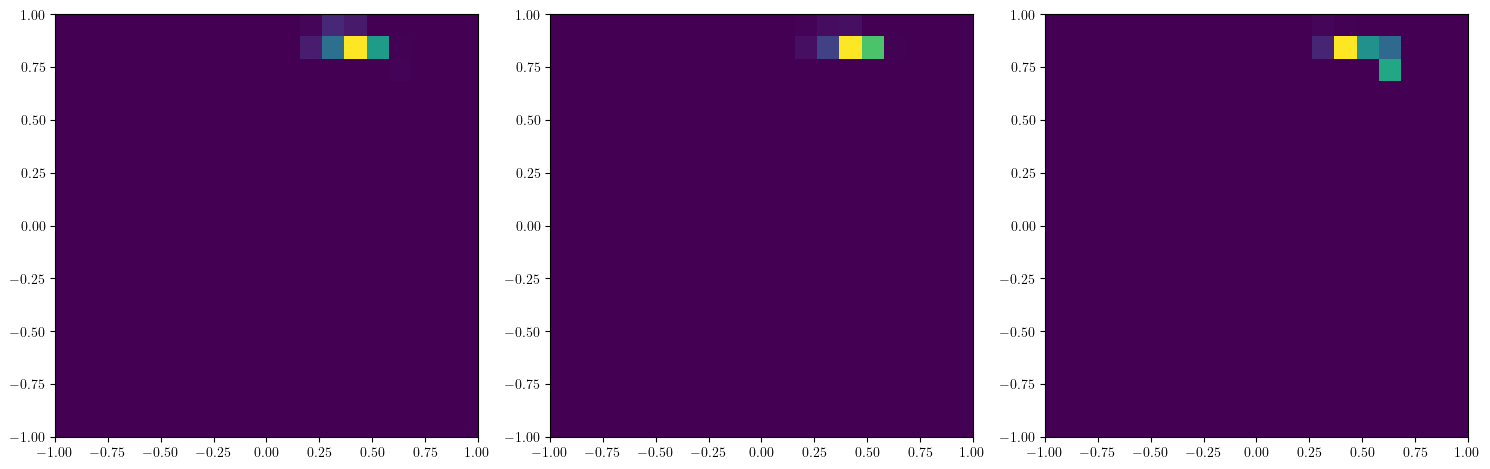

/tmp/ipykernel_1866386/2836379419.py:18: RuntimeWarning:

invalid value encountered in divide



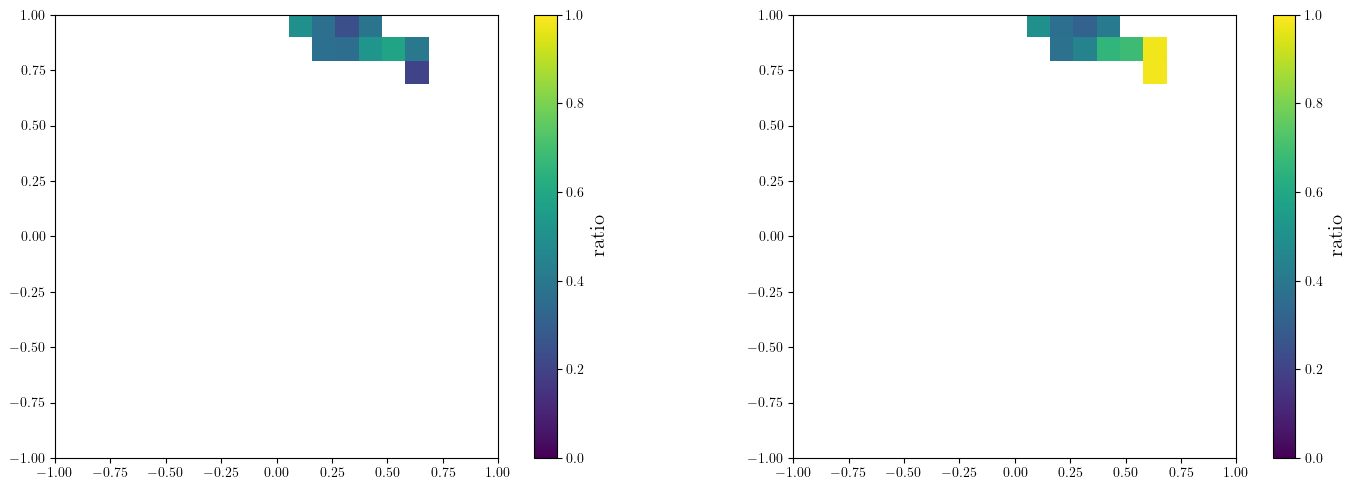

In [24]:
x_edges = np.linspace(-1, 1, 20)
y_edges = np.linspace(-1, 1, 20)
hist_3b, _, _ = np.histogram2d(base_q_repr_sampled[is_3b, f1, view], 
                               base_q_repr_sampled[is_3b, f2, view], bins=(x_edges, y_edges))
hist_bg4b, _, _ = np.histogram2d(base_q_repr_sampled[is_bg4b, f1, view], 
                                 base_q_repr_sampled[is_bg4b, f2, view], bins=(x_edges, y_edges))
hist_signal, _, _ = np.histogram2d(base_q_repr_sampled[is_signal, f1, view], 
                                   base_q_repr_sampled[is_signal, f2, view], bins=(x_edges, y_edges))

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, hist in enumerate([hist_3b, hist_bg4b, hist_signal]):
    axs[i].imshow(hist.T, origin="lower", extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]))
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for i, hist in enumerate([hist_bg4b, hist_signal + hist_bg4b]):
    axs[i].imshow((hist / (hist + hist_3b)).T, origin="lower", extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]), 
                  vmin=0, vmax=1)
    # colorbar
    cbar = plt.colorbar(axs[i].images[0], ax=axs[i])
    cbar.set_label("ratio")
plt.tight_layout()
plt.show()